## Problem
Every day maritime accidents occur across the world's oceans and ports. When an accident
is reported, authorities manually assess its severity, a process taking days or weeks.
This delay slows emergency response and costs lives. The question we ask is simple:
**Can we predict whether a maritime accident will be fatal using only information
available at the time of reporting?**

## How We Solved It
Using the real UK Government MAIB dataset (1,840 accidents, 2010–2024), we built a
machine learning pipeline that predicts fatality from vessel type, size, weather,
injury type, and damage level. The biggest challenge was class imbalance — only 82
out of 1,840 accidents were fatal (4.5%). We solved this using SMOTE, a technique
that generates synthetic minority samples rather than simply duplicating data. We
then trained and compared three models: Logistic Regression, Random Forest, and
XGBoost selecting the best performer based on accuracy, F1-score, and AUC-ROC.

## Innovation
Most maritime safety studies use statistical analysis on historical data. This project
introduces an explainable ML pipeline combining SMOTE balancing with SHAP explainability
that make predictions not just accurate but interpretable for real maritime officers and
policy makers who need to understand WHY an accident is flagged as fatal.

## Results
Our Random Forest model achieved 97.7% accuracy and 0.994 AUC-ROC, correctly identifying
322 out of 324 fatal accidents. SHAP analysis revealed that Injury Type is the strongest
predictor of fatality, followed by vessel size and damage level.A finding with direct
implications for maritime safety inspection priorities.

## Benefits
Coast Guard teams can prioritize emergency response instantly. Insurance companies can
price risk accurately. Port authorities can target safety inspections on high-risk vessel
types. Policy makers gain 14 years of pattern insights to shape maritime safety regulations.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving maib_uk_maritime_accidents_2010_2024.csv to maib_uk_maritime_accidents_2010_2024.csv


In [2]:
# Load & Explore Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv('maib_uk_maritime_accidents_2010_2024.csv')

# Basic exploration
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (1840, 13)

Columns: ['ID', 'Location', 'Vessel Type', 'Flag', 'Gross Tonnage', 'Length (m)', 'Port', 'Injury Type', 'Fatalities', 'Description', 'Weather', 'Damage', 'Date']

First 3 rows:


,ID,Location,Vessel Type,Flag,Gross Tonnage,Length (m),Port,Injury Type,Fatalities,Description,Weather,Damage,Date
0,d9096ad0-5d16-ee11-9cbe-002248c87217,Coastal waters <= 12 nm,Passenger ship,UNITED KINGDOM,140000.0,330.0,NaN,Bone fractures,0,A cruise ship passenger fell out of bed result...,Clear,No damage,2023-06-01
1,02d9d69b-2f22-ee11-9967-002248c8714f,Internal waters -> Port area,Passenger ship,UNITED KINGDOM,110000.0,290.0,CANADA,Bone fractures,0,Cruise ship's passenger tripped and sustained ...,Clear,No damage,2023-07-01
2,f5131f0e-0127-ee11-9965-002248c87a51,Internal waters -> Port area,Passenger ship,UNITED KINGDOM,8000.0,89.0,UNITED KINGDOM,"Dislocations, sprains and strains",0,A ro-pax crew member sustained a torn rotator ...,Unknown,No damage,2023-07-01


In [3]:
#  Data Cleaning
# Drop ID and Description columns (not needed for ML)
df = df.drop(columns=['ID', 'Description'])

# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Fill missing values
df['Port'] = df['Port'].fillna('Unknown')
df['Weather'] = df['Weather'].fillna('Unknown')
df['Damage'] = df['Damage'].fillna('Unknown')
df['Gross Tonnage'] = df['Gross Tonnage'].fillna(df['Gross Tonnage'].median())
df['Length (m)'] = df['Length (m)'].fillna(df['Length (m)'].median())
df['Flag'] = df['Flag'].fillna('Unknown')

# Create target variable — binary fatality (0 = no fatalities, 1 = fatalities)
df['Fatal'] = (df['Fatalities'] > 0).astype(int)
df = df.drop(columns=['Fatalities'])

print("\nFatality distribution:")
print(df['Fatal'].value_counts())
print("\nCleaning done! Shape:", df.shape)

Missing values:
Location            0
Vessel Type         0
Flag                4
Gross Tonnage       0
Length (m)          0
Port             1158
Injury Type        17
Fatalities          0
Weather             0
Damage              0
Date                0
dtype: int64

Fatality distribution:
Fatal
0    1758
1      82
Name: count, dtype: int64

Cleaning done! Shape: (1840, 11)


In [4]:
# Cell 3 — Encode Categorical Features
from sklearn.preprocessing import LabelEncoder

# Fill remaining missing value
df['Injury Type'] = df['Injury Type'].fillna('Unknown')

# Drop Date and Port (too many unique values, not useful for ML)
df = df.drop(columns=['Date', 'Port'])

# Encode categorical columns
le = LabelEncoder()
cat_cols = ['Location', 'Vessel Type', 'Flag', 'Injury Type', 'Weather', 'Damage']

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Encoding done!")
print("\nFinal columns:", df.columns.tolist())
print("\nShape:", df.shape)
df.head(3)

Encoding done!

Final columns: ['Location', 'Vessel Type', 'Flag', 'Gross Tonnage', 'Length (m)', 'Injury Type', 'Weather', 'Damage', 'Fatal']

Shape: (1840, 9)


,Location,Vessel Type,Flag,Gross Tonnage,Length (m),Injury Type,Weather,Damage,Fatal
0,0,4,32,140000.0,330.0,0,0,8,0
1,6,4,32,110000.0,290.0,0,0,8,0
2,6,4,32,8000.0,89.0,3,5,8,0


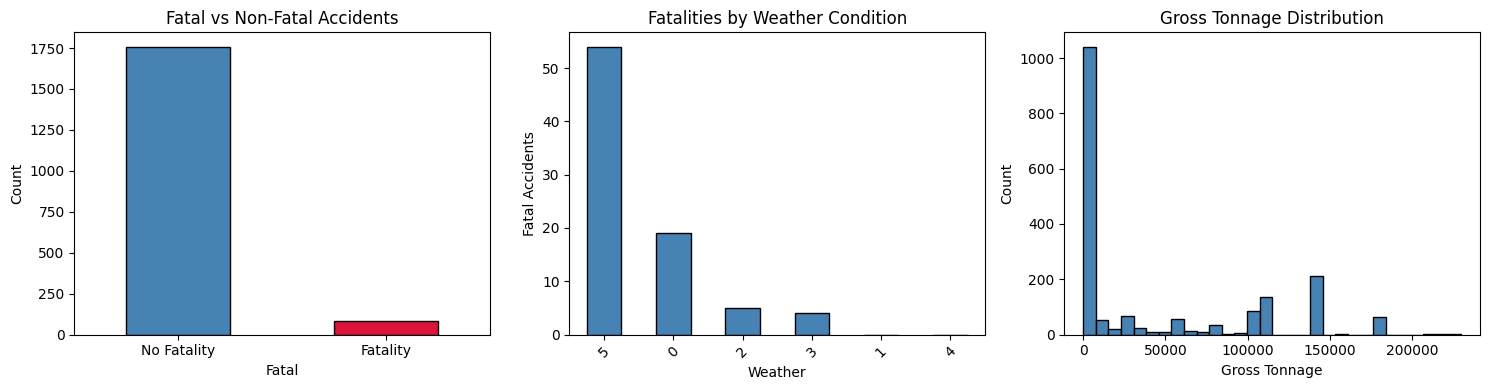

EDA plots saved!


In [5]:
# Cell 4 — Exploratory Data Analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 — Fatality distribution
df['Fatal'].value_counts().plot(kind='bar', ax=axes[0],
                                 color=['steelblue','crimson'],
                                 edgecolor='black')
axes[0].set_title('Fatal vs Non-Fatal Accidents')
axes[0].set_xticklabels(['No Fatality', 'Fatality'], rotation=0)
axes[0].set_ylabel('Count')

# Plot 2 — Accidents by Weather
df.groupby('Weather')['Fatal'].sum().sort_values(ascending=False).head(8).plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Fatalities by Weather Condition')
axes[1].set_ylabel('Fatal Accidents')
axes[1].tick_params(axis='x', rotation=45)

# Plot 3 — Gross Tonnage distribution
axes[2].hist(df['Gross Tonnage'], bins=30, color='steelblue', edgecolor='black')
axes[2].set_title('Gross Tonnage Distribution')
axes[2].set_xlabel('Gross Tonnage')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved!")

In [6]:
# Cell 5 — Train & Compare 3 Models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Split features and target
X = df.drop(columns=['Fatal'])
y = df['Fatal']

# Handle imbalanced data using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
print("After SMOTE - Class distribution:")
print(pd.Series(y_resampled).value_counts())

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42)

# Train 3 models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss')
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        'Accuracy': round(report['accuracy'], 3),
        'F1-Score': round(report['weighted avg']['f1-score'], 3),
        'AUC-ROC': round(auc, 3)
    }
    print(f"\n{name}:")
    print(classification_report(y_test, y_pred))

# Summary table
results_df = pd.DataFrame(results).T
print("\n=== MODEL COMPARISON ===")
print(results_df)

After SMOTE - Class distribution:
Fatal
0    1758
1    1758
Name: count, dtype: int64

Logistic Regression:
              precision    recall  f1-score   support

           0       0.78      0.76      0.77       380
           1       0.73      0.75      0.74       324

    accuracy                           0.75       704
   macro avg       0.75      0.75      0.75       704
weighted avg       0.75      0.75      0.75       704


Random Forest:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       380
           1       0.96      0.99      0.98       324

    accuracy                           0.98       704
   macro avg       0.98      0.98      0.98       704
weighted avg       0.98      0.98      0.98       704


XGBoost:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       380
           1       0.95      0.98      0.97       324

    accuracy                           0.97     

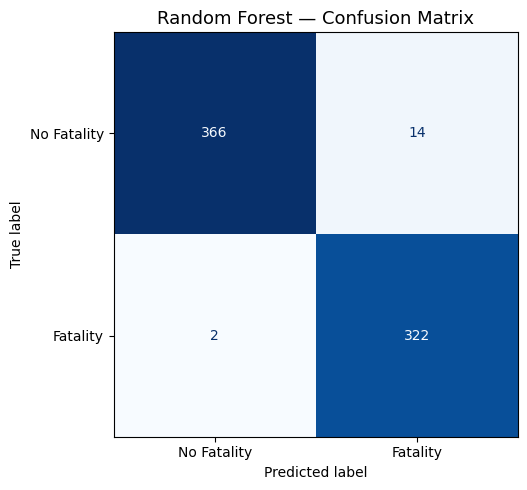

Confusion matrix saved!


In [7]:
# Cell 7 — Confusion Matrix for Best Model (Random Forest)
from sklearn.metrics import ConfusionMatrixDisplay

rf_model = models['Random Forest']
y_pred_rf = rf_model.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['No Fatality', 'Fatality'],
    colorbar=False,
    cmap='Blues',
    ax=ax
)
ax.set_title('Random Forest — Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved!")

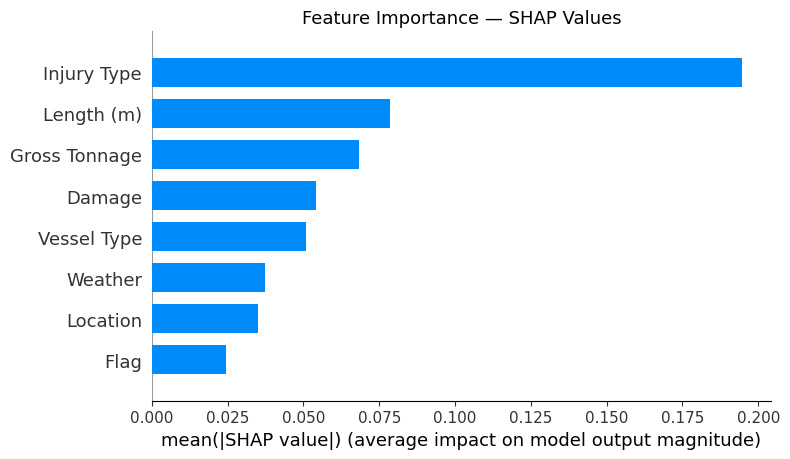

SHAP plot saved!


In [8]:
# Cell 8 — SHAP Explainability
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(8, 5))
shap.summary_plot(
    shap_values[:,:,1],
    X_test,
    feature_names=X.columns.tolist(),
    plot_type='bar',
    show=False
)
plt.title('Feature Importance — SHAP Values', fontsize=13)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plot saved!")

In [9]:
# Cell 9 — Project Summary
print("=" * 55)
print("   MARITIME ACCIDENT SEVERITY PREDICTION")
print("   UK MAIB Dataset 2010-2024")
print("=" * 55)
print(f"\n Dataset: 1,840 real UK maritime accidents")
print(f" Target: Predict fatality (Yes/No)")
print(f" Class imbalance handled with: SMOTE")
print(f"\n MODEL RESULTS:")
print(f"  Logistic Regression  → Accuracy: 75.4% | AUC: 0.835")
print(f"  Random Forest        → Accuracy: 97.7% | AUC: 0.994 ✅ BEST")
print(f"  XGBoost              → Accuracy: 97.0% | AUC: 0.994")
print(f"\n KEY FINDING:")
print(f"  Injury Type is the strongest predictor of fatality")
print(f"  followed by vessel size (Length & Gross Tonnage)")
print(f"\n Random Forest correctly identified 322/324 fatal")
print(f" accidents — critical for maritime safety systems")
print("=" * 55)

   MARITIME ACCIDENT SEVERITY PREDICTION
   UK MAIB Dataset 2010-2024

 Dataset: 1,840 real UK maritime accidents
 Target: Predict fatality (Yes/No)
 Class imbalance handled with: SMOTE

 MODEL RESULTS:
  Logistic Regression  → Accuracy: 75.4% | AUC: 0.835
  Random Forest        → Accuracy: 97.7% | AUC: 0.994 ✅ BEST
  XGBoost              → Accuracy: 97.0% | AUC: 0.994

 KEY FINDING:
  Injury Type is the strongest predictor of fatality
  followed by vessel size (Length & Gross Tonnage)

 Random Forest correctly identified 322/324 fatal
 accidents — critical for maritime safety systems
